## Εργασία - Αναγνώριση Προτύπων & Μηχανική Μάθηση 2025-2026

Μανωλίδου Ανατολή 10874 amanolid@ece.auth.gr  
Σκλαβενίτης Γεώργιος 10708 gsklaven@ece.auth.gr



### Μέρος Α   
 Σε αυτή την άσκηση θα χρησιμοποιήσετε το σύνολο δεδομένων στο αρχείο dataset1.csv. Το σύνολο αυτό αποτελείται από 300 γραμμές δειγμάτων δύο διαστάσεων (οι δύο πρώτες στήλες αντιστοιχούν στα δεδομένα και η τελευταία στήλη στην ετικέτα), τα οποία ανήκουν σε 3 κλάσεις. Οι πρώτες 100 γραμμές ανήκουν στην κλάση 0, οι επόμενες 100 στην κλάση 1 κ.ο.κ. Θεωρήστε ότι τα δείγματα κάθε κλάσης προέρχονται από διαφορετική κανονική κατανομή. Σας ζητείται να χρησιμοποιήσετε την τεχνική της Μέγιστης Πιθανοφάνειας για να βρείτε τις παραμέτρους αυτών των τριών διαφορετικών κανονικών κατανομών. Δεν επιτρέπεται να χρησιμοποιήσετε συναρτήσεις βιβλιοθηκών. Επιτρέπεται να χρησιμοποιήσετε βασικές συναρτήσεις για πράξεις με πίνακες, όπως np.sum κ.λ.π. Σχεδιάστε και τις 3 κατανομές σε ένα ενιαίο 3D plot.

Class 0 MLE Mean:
[29.20903802 16.84988855]
Class 0 MLE Covariance:
[[46.98591258 22.90532295]
 [22.90532295 48.63133559]]

Class 1 MLE Mean:
[40.19766916 34.28109099]
Class 1 MLE Covariance:
[[ 9.42390491 11.48971771]
 [11.48971771 20.10805596]]

Class 2 MLE Mean:
[27.55232503 34.79318037]
Class 2 MLE Covariance:
[[13.96874391 11.77433636]
 [11.77433636 25.28848192]]



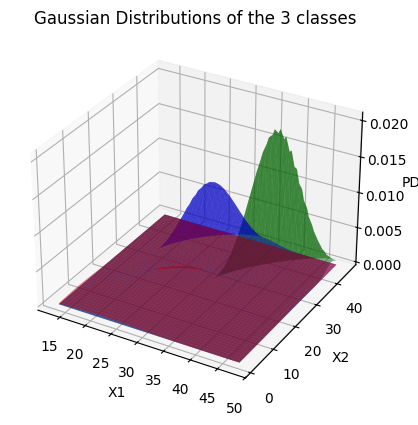

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('dataset1.csv', delimiter=',')
X = data[:, :2]
y = data[:, 2].astype(int)

num_classes = 3
N = 100
d = 2

means = []
covariances = []

# Maximum Likelihood Estimation for each class
for c in range(num_classes):
    Xc = X[y == c]

    mean = np.sum(Xc, axis=0) / N
    means.append(mean)

    cov = np.zeros((d, d))
    for i in range(N):
        diff = (Xc[i] - mean).reshape(-1, 1)
        cov += diff @ diff.T
    cov = cov / N
    covariances.append(cov)
    print(f"Class {c} MLE Mean:\n{mean}")
    print(f"Class {c} MLE Covariance:\n{cov}\n")

# 3D plot of the three Gaussians
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b']
for c in range(num_classes):
    mean = means[c]
    cov = covariances[c]

    x = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 50)
    y_ = np.linspace(np.min(X[:,1]), np.max(X[:,1]), 50)
    Xg, Yg = np.meshgrid(x, y_)
    pos = np.empty(Xg.shape + (2,))
    pos[:, :, 0] = Xg
    pos[:, :, 1] = Yg

    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    norm_const = 1.0 / (2 * np.pi * np.sqrt(det_cov))
    Z = np.zeros(Xg.shape)
    diff = pos - mean
    expo = (
    diff[:, :, 0] * (inv_cov[0,0] * diff[:, :, 0] + inv_cov[0,1] * diff[:, :, 1]) +
    diff[:, :, 1] * (inv_cov[1,0] * diff[:, :, 0] + inv_cov[1,1] * diff[:, :, 1])
    )
    Z = norm_const * np.exp(-0.5 * expo)

    ax.plot_surface(Xg, Yg, Z, color=colors[c], alpha=0.5)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('PDF')
plt.title('Gaussian Distributions of the 3 classes')
plt.show()

### Μέρος Β

Σε αυτή την άσκηση θα εργαστείτε με το σύνολο δεδομένων στο αρχείο dataset2.csv. Περιλαμβάνει 200 μονοδιάστατα δείγματα (200 γραμμές, 1 στήλη). Το έργο σας είναι να υλοποιήσετε τη μέθοδο παραθύρων Parzen για να εκτιμήσετε τη συνάρτηση πυκνότητας πιθανότητας της κατανομής των δεδομένων. Αφού υλοποιήσετε τον κώδικα της παραπάνω μεθόδου, υποθέστε ότι το σύνολο δεδομένων που έχετε προέρχεται από την μονοδιάστατη κανονική κατανομή N(1, 4). Βρείτε την καταλληλότερη τιμή για το h βασιζόμενοι σε αυτή
τη γνώση. Δημιουργήστε ένα ιστόγραμμα των δεδομένων για να επιβεβαιώσετε ότι πράγματι προέρχονται από την παραπάνω κατανομή. Για κάθε h στο εύρος [0.1, 10] με βήμα = 0.1, υπολογίστε: την προβλεπόμενη πιθανοφάνεια για κάθε σημείο στα δεδομένα, την πραγματική πιθανοφάνεια (μπορείτε να χρησιμοποιήσετε την συνάρτηση της κανονικής κατανομής) και το τετραγωνικό σφάλμα μεταξύ των δύο. Επαναλάβετε αυτή τη διαδικασία και για τα δύο kernels (υπερκύβος και γκαουσιανή). Τέλος, εκτυπώστε την καταλληλότερη τιμή του h για κάθε kernel και δημιουργήστε ένα plot (ένα για κάθε kernel) το οποίο να δείχνει τις τιμές του h στον άξονα x και το σφάλμα στον άξονα y.

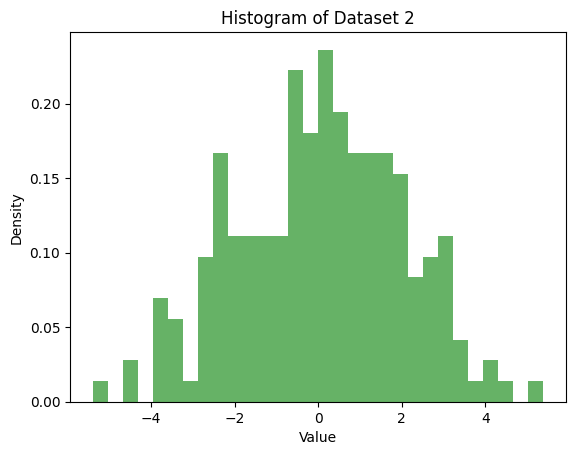

Best h for Gaussian Kernel: 0.8
Best h for Hypercube Kernel: 2.8


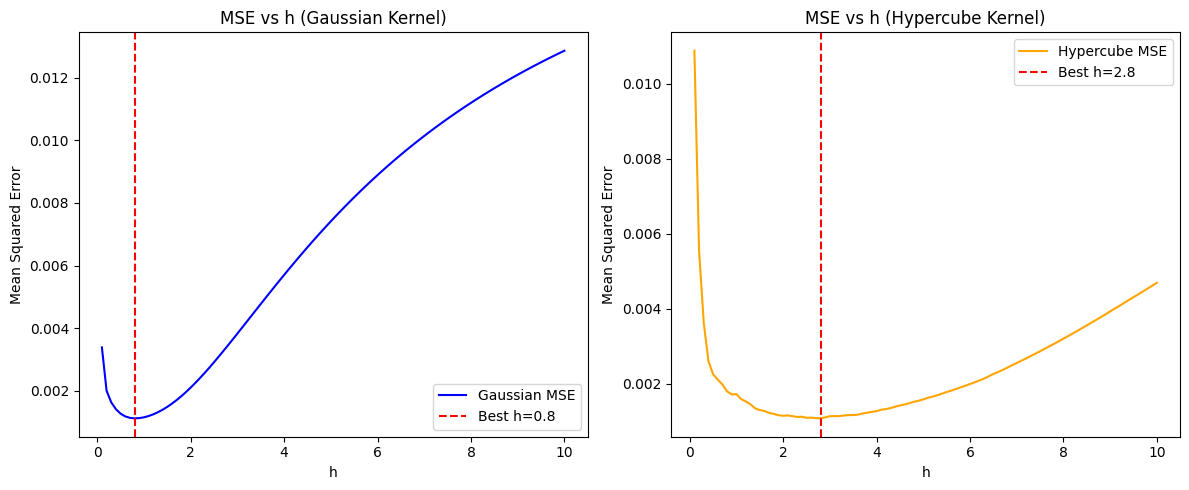

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('dataset2.csv')
X = data[:]
N = X.shape[0]
d = 1

# Histogram to verify data distribution
plt.hist(X, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Dataset 2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (u**2))

def hypercube_kernel(u):
    return (np.abs(u) <= 0.5).astype(float)

def true_pdf(x):
    mu = 1
    sigma = 2
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

h_values = np.arange(0.1, 10.1, 0.1)
mse_gaussian = []
mse_hypercube = []

for h in h_values:
    errors_g = []
    errors_h = []

    for x_target in X:
        u = (x_target - X) / h

        p_hat_g = np.sum(gaussian_kernel(u)) / (N * h)
        p_hat_h = np.sum(hypercube_kernel(u)) / (N * h)
        p_real = true_pdf(x_target)

        errors_g.append((p_hat_g - p_real)**2)
        errors_h.append((p_hat_h - p_real)**2)

    mse_gaussian.append(np.mean(errors_g))
    mse_hypercube.append(np.mean(errors_h))

best_h_g = h_values[np.argmin(mse_gaussian)]
best_h_h = h_values[np.argmin(mse_hypercube)]

print(f"Best h for Gaussian Kernel: {best_h_g:.1f}")
print(f"Best h for Hypercube Kernel: {best_h_h:.1f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_values, mse_gaussian, color='blue', label='Gaussian MSE')
plt.axvline(best_h_g, color='red', linestyle='--', label=f'Best h={best_h_g:.1f}')
plt.title('MSE vs h (Gaussian Kernel)')
plt.xlabel('h')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h_values, mse_hypercube, color='orange', label='Hypercube MSE')
plt.axvline(best_h_h, color='red', linestyle='--', label=f'Best h={best_h_h:.1f}')
plt.title('MSE vs h (Hypercube Kernel)')
plt.xlabel('h')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.tight_layout()
plt.show()

### Μέρος Γ
Σε αυτή την άσκηση θα αναπτύξετε έναν ταξινομητή k Nearest Neighbors (KNN). Θα χρησιμοποιήσετε το σύνολο
δεδομένων dataset3.csv για εκπαίδευση και το testset.csv για δοκιμή. Τα αρχεία αποτελούνται από 50 δείγματα
δύο διαστάσεων το καθένα, μαζί με τις ετικέτες τους στην τελευταία στήλη (50 γραμμές και 3 στήλες).
Αρχικά, υλοποιήστε μια συνάρτηση eucl(x, trainData) που να επιστρέφει την ευκλείδεια απόσταση του x από
όλα τα σημεία στο trainData. Μην χρησιμοποιείτε συναρτήσεις βιβλιοθηκών, εκτός από βασικές πράξεις με πίνακες.
Κατόπιν, υλοποιήστε μια συνάρτηση neighbors(x, trainData, k), όπου k είναι ο αριθμός των γειτόνων. Η
συνάρτηση πρέπει να υπολογίζει την απόσταση του x από όλα τα σημεία στο trainData να ταξινομεί τις αποστάσεις
σε φθίνουσα σειρά, και να επιστρέφει τα k κορυφαία σημεία από το trainData.
Τέλος, υλοποιήστε μια συνάρτηση predict(testData, trainData, k), όπου θα καλεί τη συνάρτηση neighbors για
κάθε σημείο στο testData, στη συνέχεια θα υπολογίζει την πιθανότητα κάθε σημείου να ανήκει στην κλάση 0 ή
στην κλάση 1 (οι πιθανότητες αυτές πρέπει να αθροίζουν στο 1). Τέλος, πρέπει να επιστρέφει δύο πιθανότητες για
κάθε σημείο στο testData.
Τώρα θα χρησιμοποιήσετε το test set για να βρείτε την καλύτερη τιμή του k και την ακρίβειά του. Για k στο
εύρος [1, 30], υπολογίστε την ακρίβεια κάθε ταξινομητή χρησιμοποιώντας τα δεδομένα από το αρχείο testset.csv.
Εκτυπώστε την καλύτερη τιμή του k μαζί με την ακρίβειά της και δημιουργήστε ένα plot με τις τιμές του k στον
άξονα x και την ακρίβεια στον άξονα y.
Τέλος, θα σχεδιάσετε τα όρια απόφασης του καλύτερου ταξινομητή (χρησιμοποιώντας την τιμή του k που
βρήκατε προηγουμένως). Μπορείτε να χρησιμοποιήσετε τη συνάρτηση contourf για να σχεδιάσετε τις περιοχές
απόφασης.

Best k: 11 with Accuracy: 74.00%


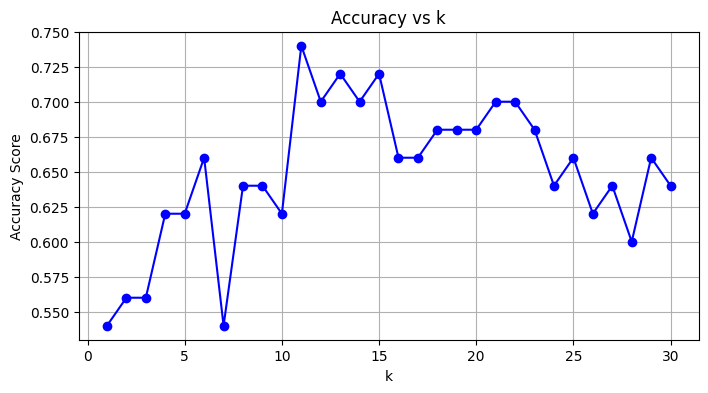

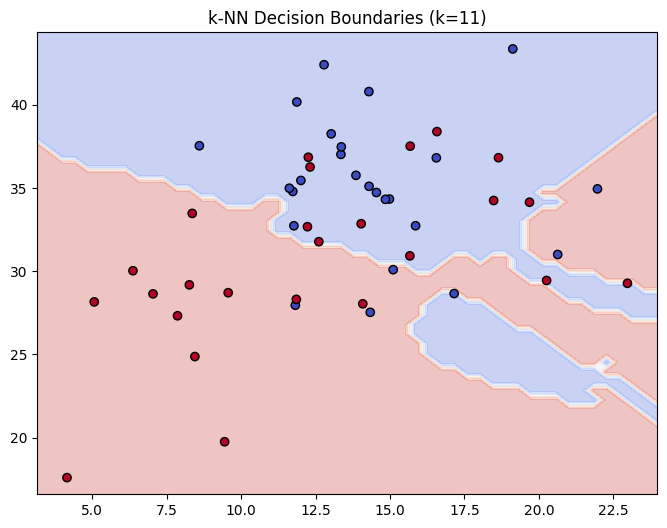

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

trainData = np.loadtxt('dataset3.csv', delimiter=',')
testData = np.loadtxt('testset.csv', delimiter=',')
y_test = testData[:, 2].astype(int)

def eucl(x, trainData):
    diff = trainData[:, :2] - x
    return np.sqrt(np.sum(diff**2, axis=1))

def neighbors(x, trainData, k):
    distances = eucl(x, trainData)
    nearest_indices = np.argsort(distances)[:k]
    return trainData[nearest_indices]

def predict(testData, trainData, k):
    predictions_probs = []
    for x in testData[:, :2]:
        k_neighbors = neighbors(x, trainData, k)
        labels = k_neighbors[:, 2]

        prob_1 = np.sum(labels == 1) / k
        prob_0 = 1 - prob_1
        predictions_probs.append([prob_0, prob_1])

    return np.array(predictions_probs)

# Find optimal k
k_range = np.arange(1, 31)
accuracies = []

for k in k_range:
    probs = predict(testData, trainData, k)
    y_pred = (probs[:, 1] > 0.5).astype(int)
    accuracies.append(np.mean(y_pred == y_test))

best_k = k_range[np.argmax(accuracies)]
print(f"Best k: {best_k} with Accuracy: {max(accuracies)*100:.2f}%")

# Accuracy plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o', color='blue')
plt.title('Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

# Decision boundaries
x_min, x_max = trainData[:, 0].min() - 1, trainData[:, 0].max() + 1
y_min, y_max = trainData[:, 1].min() - 1, trainData[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))

grid_pts = np.c_[xx.ravel(), yy.ravel(), np.zeros(xx.size)]
grid_probs = predict(grid_pts, trainData, best_k)
Z = (grid_probs[:, 1] > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(trainData[:, 0], trainData[:, 1], c=trainData[:, 2], cmap='coolwarm', edgecolors='black')
plt.title(f"k-NN Decision Boundaries (k={best_k})")
plt.show()